## Strategy backtest II

- Same procedure as **Strategy Backtest I**
- NVDA price has an upward trend on 2026-07-01, which is used in Backtest I
- Backtest II uses NVDA price on 2026-07-02, which has a downward trend
- Upward trend: hard to beat arrival ask price; downward trend: easier to beat arrival ask price; expect backtest II to outperform backtest I

Results reported using NVDA MBP data on 2026-07-02.

### Raw Data Loading

Load raw MBP-10 ticks, trim the opening/closing minutes, and truncate to `data_depth` book levels. Then split off a holdout period (`data_holdout`) which is reserved for out-of-sample validation of any hyperparameters tuned on `data_train`.

In [16]:
### Data Loading
from execution_timing.data_loading import read_raw_data, truncate_depth, holdout_split
from execution_timing.config import FACTOR_HYPERPARAMETERS_DIRECTION, LABEL_HYPERPARAMETERS
from execution_timing.feature_engineering import load_factors_and_labels
from execution_timing.rolling_window_generator import RollingWindowGenerator, Window

data_mbp10 = read_raw_data('data_raw/nvda_mbp-10_2026-07-02.parquet', trim_open_and_close=True)
data_depth = 3
data = truncate_depth(data_mbp10, data_depth)
data_train, data_holdout = holdout_split(data, holdout_mins=120, purge_ticks=0)
print(f"Train data shape: {data_train.shape}")
print(f"Holdout data shape: {data_holdout.shape}")

Train data shape: (3115053, 12)
Holdout data shape: (1161317, 12)


### Feature Engineering

Build the direction factors (`FACTOR_HYPERPARAMETERS_DIRECTION`) and the `ask_return_direction` label on `data_train`, and split into rolling train/test windows (`RollingWindowGenerator`) for walk-forward backtesting.

In [17]:
factors, labels = load_factors_and_labels(
    data=data_train,
    data_depth=data_depth,
    factor_hyperparameters=FACTOR_HYPERPARAMETERS_DIRECTION,
    label_hyperparameters=LABEL_HYPERPARAMETERS,
    dropna=True)

X = factors
y = labels['ask_return_direction']
rolling_window_generator = RollingWindowGenerator(X=X,
                                                  y=y,
                                                  train_window_size_mins=25,
                                                  test_window_size_mins=5,
                                                  step_size_mins=5,
                                                  purge_secs=1)
windows = list(iter(rolling_window_generator))
print(f"Windows count: {len(windows)}")
print(f"Windows start time: {windows[0].train_start}")
print(f"Windows end time: {windows[-1].test_end}")

Dropped 600 rows with NaN values
Windows count: 37
Windows start time: 2026-07-02 10:00:00-04:00
Windows end time: 2026-07-02 13:30:00-04:00


### Run Trading Simulation

- `PredictionModel` -- wraps `LogisticRegression` which is used to predict future price direction
- `StrategyDirection` -- converts model prediction into 0/1 trading signal
- `TradingSimulator` -- turns trading signal into fills against raw ask/bid ticks.

`run_simulation` walks forward window by window, retraining, predicting, generating the signal, and simulating fills, returning the per-minute trade results (`trading_result`) and each window's fitted factor coefficients (`model_coeff`).

In [18]:
from execution_timing.prediction_model import PredictionModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from execution_timing.trading_strategy import StrategyDirection
from execution_timing.trading_simulator import TradingSimulator, run_simulation


dir_model = PredictionModel(
    model=LogisticRegression(l1_ratio=0, # penalty = l1_ratio * L1 + (1 − l1_ratio) * L2; l1_ratio=0 -> Ridge
                           C=0.01, # C=1/alpha where alpha is the coefficient for penalty term; bigger alpha mode penalty
                           max_iter=10000,),
    scaler=StandardScaler(),
)

strategy = StrategyDirection(dir_pred_model=dir_model,
                             dir_threshold=0.56,
                             sig_resample_freq=None)
trading_simulator = TradingSimulator(raw_price=data_train[['ask_px_00', 'bid_px_00']],
                             execution_lag_ticks=0)


In [19]:
trading_result, model_coeff = run_simulation(strategy=strategy,
                            trading_simulator=trading_simulator,
                            windows=windows)

In [20]:
display(trading_result)

,#window,execution_time,execution_second,fill_price,arrival_ask,departure_ask,mean_ask,max_ask,min_ask,arrival_bid,departure_bid,arrival_spread,departure_spread,pnl,pnl_pct_spread
2026-07-02 10:25:00-04:00,0,2026-07-02 10:25:01.048167315-04:00,1.048167,198.56,198.51,198.59,198.440874,198.64,198.24,198.48,198.57,0.03,0.02,-0.05,-1.666667
2026-07-02 10:26:00-04:00,0,2026-07-02 10:26:02.168350855-04:00,2.168351,198.67,198.59,198.58,198.574807,198.75,198.44,198.57,198.56,0.02,0.02,-0.08,-4.000000
2026-07-02 10:27:00-04:00,0,2026-07-02 10:27:01.440276854-04:00,1.440277,198.53,198.58,197.73,198.072975,198.60,197.67,198.56,197.71,0.02,0.02,0.05,2.500000
2026-07-02 10:28:00-04:00,0,2026-07-02 10:28:03.584499192-04:00,3.584499,197.73,197.73,197.68,197.633432,197.84,197.45,197.71,197.65,0.02,0.03,0.00,0.000000
2026-07-02 10:29:00-04:00,0,2026-07-02 10:29:00.794575782-04:00,0.794576,197.68,197.68,197.86,197.829693,198.00,197.66,197.66,197.83,0.02,0.03,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-02 13:25:00-04:00,36,2026-07-02 13:25:59.971293011-04:00,59.971293,192.89,192.97,192.89,192.958104,193.05,192.86,192.95,192.87,0.02,0.02,0.08,4.000000
2026-07-02 13:26:00-04:00,36,2026-07-02 13:26:59.975163073-04:00,59.975163,192.84,192.89,192.84,192.896806,193.01,192.77,192.87,192.83,0.02,0.01,0.05,2.500000
2026-07-02 13:27:00-04:00,36,2026-07-02 13:27:59.887334419-04:00,59.887334,192.93,192.84,192.93,192.954378,193.01,192.84,192.83,192.92,0.01,0.01,-0.09,-9.000000
2026-07-02 13:28:00-04:00,36,2026-07-02 13:28:59.923892764-04:00,59.923893,193.01,192.93,193.01,192.972048,193.03,192.91,192.92,192.99,0.01,0.02,-0.08,-8.000000


In [21]:
display(model_coeff)

,window_0,window_1,window_2,window_3,window_4,window_5,window_6,window_7,window_8,window_9,...,window_27,window_28,window_29,window_30,window_31,window_32,window_33,window_34,window_35,window_36
obi_weighted,0.118294,0.061705,0.050775,0.060858,0.046440,0.046691,0.044011,0.077082,0.068738,0.080543,...,0.167796,0.150204,0.134130,0.132246,0.114262,0.089290,0.073444,0.086065,0.086782,0.090794
spread_deviation,-0.149131,-0.145460,-0.131119,-0.122310,-0.100358,-0.089695,-0.103925,-0.134044,-0.147171,-0.185650,...,-0.160101,-0.162631,-0.181029,-0.176402,-0.135873,-0.171407,-0.145738,-0.127944,-0.131038,-0.142954
ask_px_momentum,0.078129,0.035997,0.035675,0.027691,0.001007,-0.020804,0.008792,0.022770,0.029666,0.058781,...,0.028366,0.017751,0.033021,0.037059,0.002619,0.014961,0.013179,0.001018,0.001384,0.017692
bid_px_momentum,-0.003845,0.019422,0.038574,0.043046,0.049844,0.047156,0.038631,-0.008265,-0.014474,-0.029060,...,0.045907,0.046115,0.034846,0.053649,0.077089,0.022088,0.037289,0.044333,0.033306,0.020960
vwap_mid_deviation_ask,-0.061381,-0.053364,-0.055937,-0.047227,-0.051315,-0.084085,-0.077844,-0.091732,-0.088734,-0.075750,...,-0.023042,-0.023287,-0.015112,-0.004868,-0.012338,-0.046166,-0.049027,-0.048804,-0.069210,-0.068779


### Trade Result Evaluation

Summary metrics (cumulative/mean pnl, win rate, Sharpe ratio, trigger rate) plus diagnostic plots.

In [22]:
from execution_timing.visualization import (plot_cumulative_pnl,
                                            plot_execution_second_distribution,
                                            plot_pnl_histogram,
                                            plot_price_path,
                                            plot_coefficient_distribution,
                                            plot_price_and_pnl)
from execution_timing.trading_simulator import summarize_results, baseline_comparison

stats = summarize_results(trading_result)
display(stats)

,cumulative_pnl,win_rate,sharpe_ratio,mean_pnl,mean_pnl_pct_spread,trigger_rate,mean_arrival_spread
stats,3.09,0.524324,0.128518,0.016703,0.922523,0.708108,0.018595


In [23]:
baseline_stats = baseline_comparison(trading_result)
display(baseline_stats)

,mean_pnl_per_share
buy_immediately,0.000000
random_tick,0.008609
always_wait,0.029189
model_timed,0.016703
perfect_foresight,0.168649


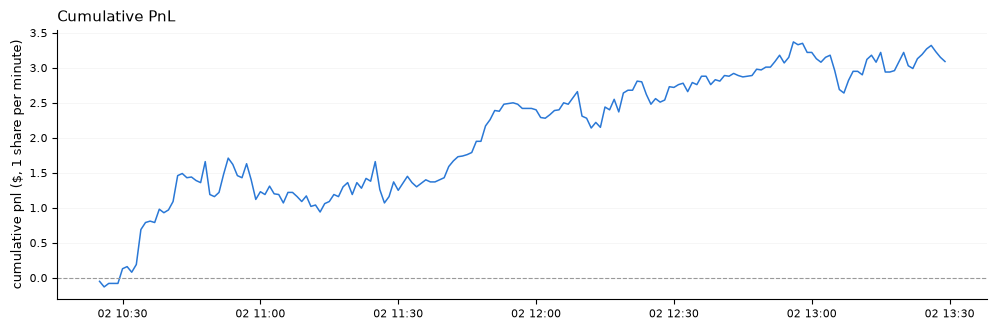

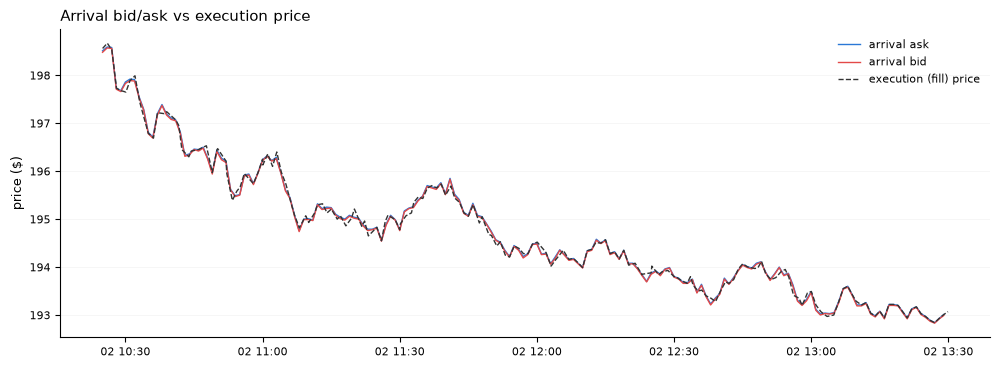

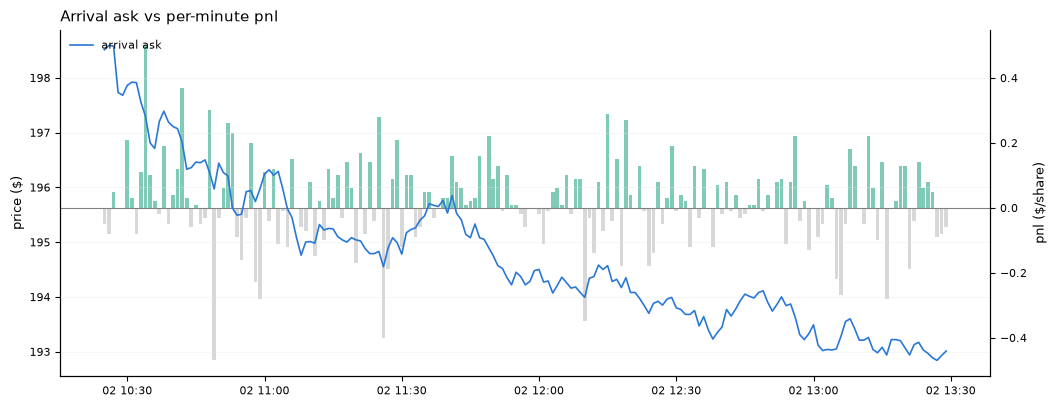

In [24]:
# cumulative pnl over the backtest
plot_cumulative_pnl(trading_result['pnl'].cumsum())

# arrival/departure bid-ask vs execution (fill) price, per minute
plot_price_path(trading_result)

# arrival ask overlaid with per-minute pnl on the same time axis
plot_price_and_pnl(trading_result)

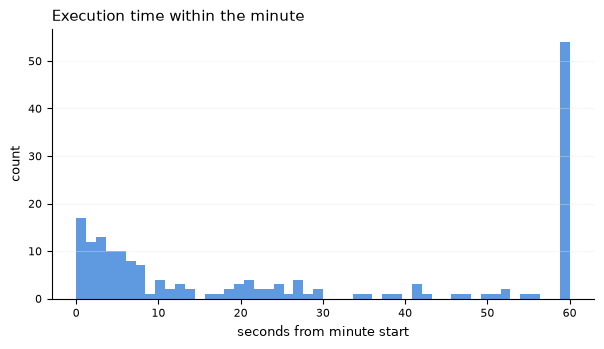

In [25]:
# when does execution happen in each minute
plot_execution_second_distribution(trading_result['execution_second'], bins=50)

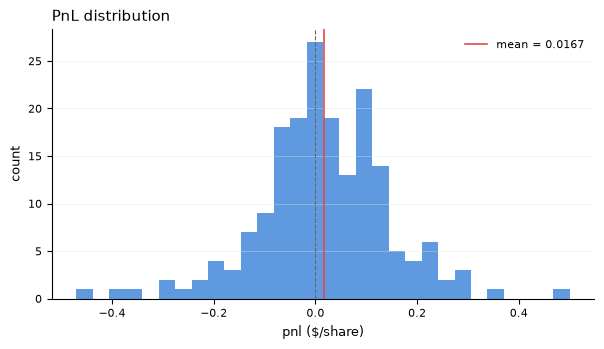

In [26]:
# per-minute pnl distribution
plot_pnl_histogram(trading_result['pnl'], bins=30)

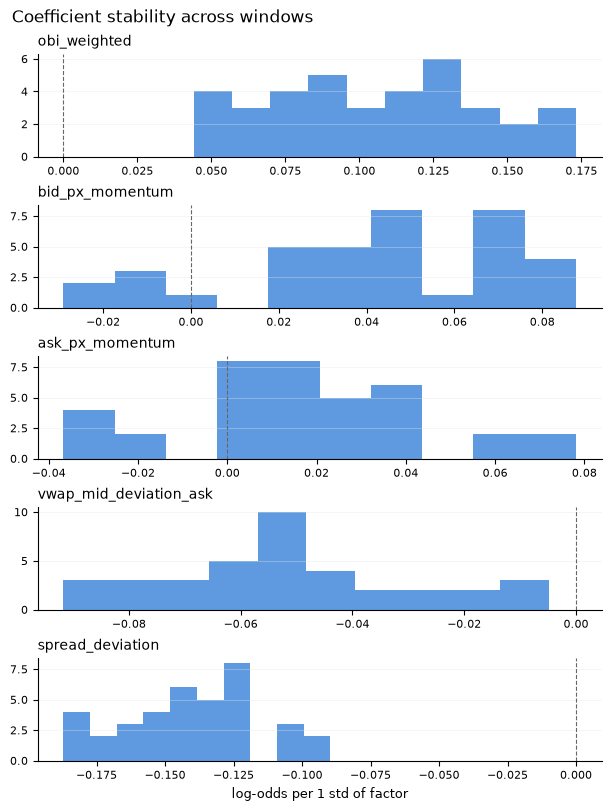

In [27]:
# per-factor coefficient stability across rolling windows; expect signs to be stable
plot_coefficient_distribution(model_coeff, bins=10)

### Holdout Evaluation
- True out-of-sample data which was never used before.
- Same pipeline (feature engineering -> rolling windows -> `run_simulation` -> `summarize_results` + plots) as above, run on `data_holdout` instead of `data_train`.

Dropped 600 rows with NaN values
Windows count: 19
Windows start time: 2026-07-02 13:30:00-04:00
Windows end time: 2026-07-02 15:30:00-04:00


,cumulative_pnl,win_rate,sharpe_ratio,mean_pnl,mean_pnl_pct_spread,trigger_rate,mean_arrival_spread
stats,0.29,0.442105,0.034668,0.003053,0.435088,0.652632,0.015053


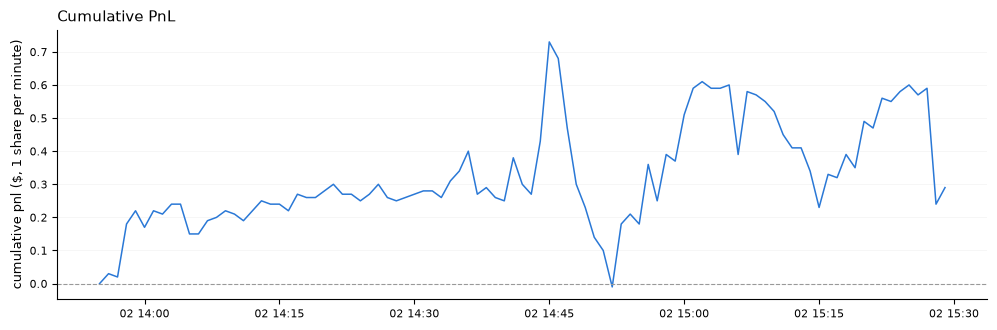

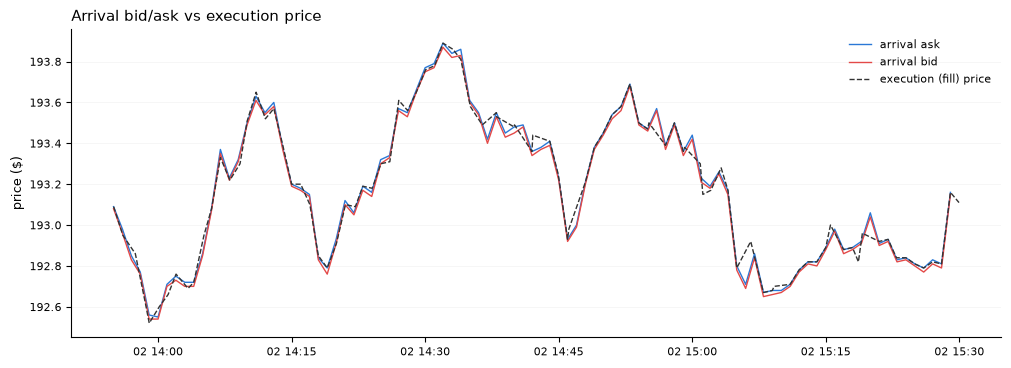

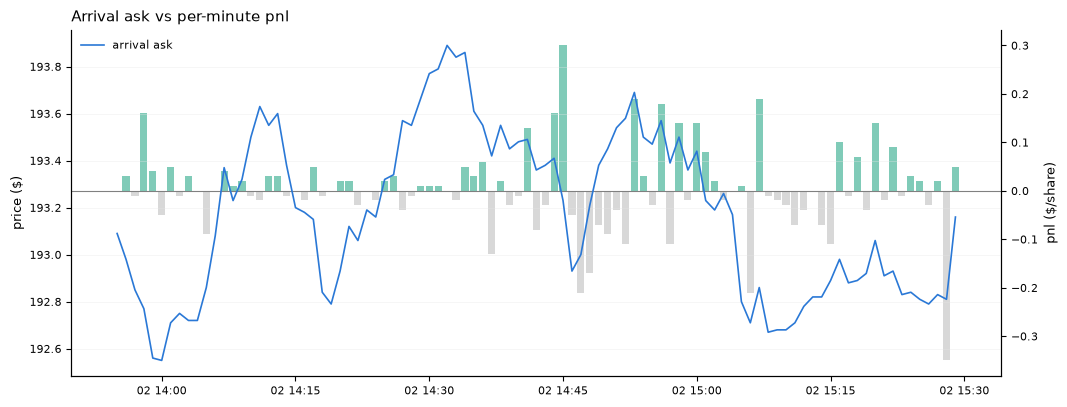

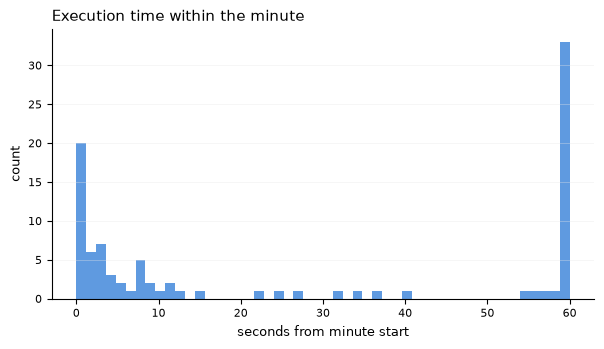

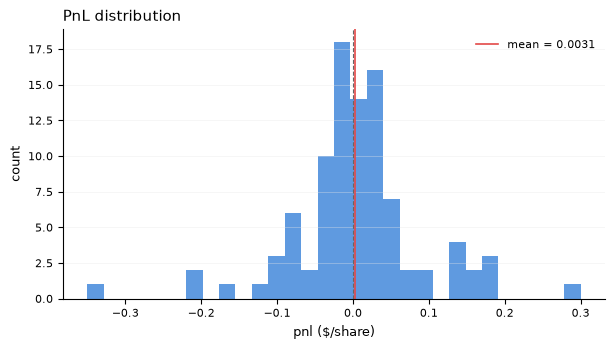

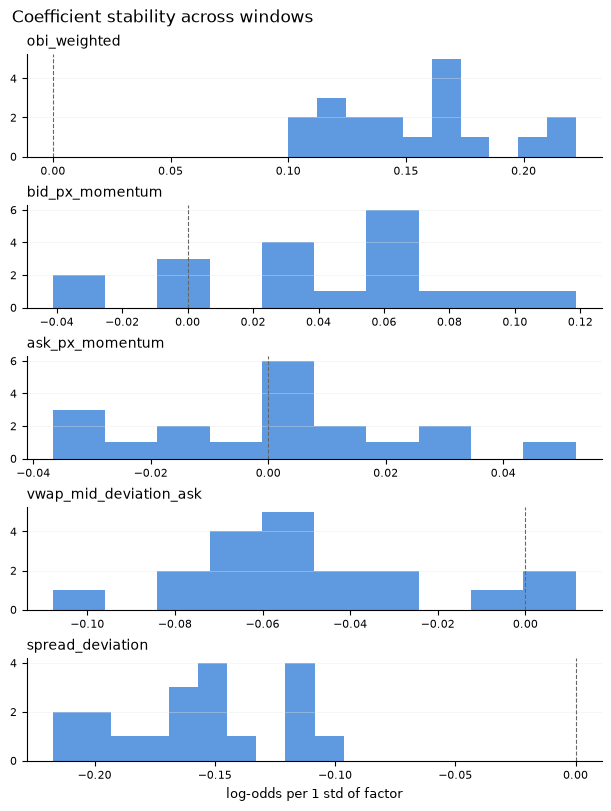

In [29]:
def backtest_and_evaluate(data,
                          data_depth=data_depth,
                          factor_hyperparameters=FACTOR_HYPERPARAMETERS_DIRECTION,
                          label_hyperparameters=LABEL_HYPERPARAMETERS,
                          train_window_size_mins=25,
                          test_window_size_mins=5,
                          step_size_mins=5,
                          purge_secs=1,
                          dir_threshold=0.56,
                          sig_resample_freq=None,
                          execution_lag_ticks=0,
                          ):
    """
    Same steps as the sections above, parameterized by `data` so the whole
    pipeline can be re-run on a different split (e.g. data_holdout) without
    duplicating the cells.
    """
    factors, labels = load_factors_and_labels(
        data=data,
        data_depth=data_depth,
        factor_hyperparameters=factor_hyperparameters,
        label_hyperparameters=label_hyperparameters,
        dropna=True)

    X = factors
    y = labels['ask_return_direction']
    rolling_window_generator = RollingWindowGenerator(X=X,
                                                      y=y,
                                                      train_window_size_mins=train_window_size_mins,
                                                      test_window_size_mins=test_window_size_mins,
                                                      step_size_mins=step_size_mins,
                                                      purge_secs=purge_secs)
    windows = list(iter(rolling_window_generator))
    print(f"Windows count: {len(windows)}")
    if windows:
        print(f"Windows start time: {windows[0].train_start}")
        print(f"Windows end time: {windows[-1].test_end}")

    dir_model = PredictionModel(
        model=LogisticRegression(l1_ratio=0, C=0.01, max_iter=10000),
        scaler=StandardScaler(),
    )
    strategy = StrategyDirection(dir_pred_model=dir_model,
                                 dir_threshold=dir_threshold,
                                 sig_resample_freq=sig_resample_freq)
    trading_simulator = TradingSimulator(raw_price=data[['ask_px_00', 'bid_px_00']],
                                         execution_lag_ticks=execution_lag_ticks)

    trading_result, model_coeff = run_simulation(strategy=strategy,
                                                 trading_simulator=trading_simulator,
                                                 windows=windows)

    stats = summarize_results(trading_result)
    display(stats)

    plot_cumulative_pnl(trading_result['pnl'].cumsum())
    plot_price_path(trading_result)
    plot_price_and_pnl(trading_result)
    plot_execution_second_distribution(trading_result['execution_second'], bins=50)
    plot_pnl_histogram(trading_result['pnl'], bins=30)
    plot_coefficient_distribution(model_coeff, bins=10)

    return trading_result, model_coeff, stats
trading_result_holdout, model_coeff_holdout, stats_holdout = backtest_and_evaluate(data_holdout)